# Using Constraint

In density functional theory (DFT) calculations, geometry optimization is used to relax atomic positions and minimize the total energy of a system. In many practical cases, full relaxation of all atoms or lattice parameters is not required. Geometric constraints are therefore applied to restrict the movement of selected atoms or cell degrees of freedom during optimization. In SIESTA, constraints are defined using the **Geometry.Constraints**block in the input file. Constrained atoms remain fixed while unconstrained atoms relax under interatomic forces. This approach is commonly used in surface, adsorption, and defect calculations to preserve bulk-like regions, reduce computational cost, and obtain physically meaningful structures.

---


In [1]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/03-constraints


In [2]:
!mkdir -p EX1

In [3]:
ls


EX1/  si8.fdf  Si.psml  Untitled.ipynb


In [4]:
!cp si8.fdf  Si.psml EX1/

In [5]:
%cd EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/structure-optimization/03-constraints/EX1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
ls

si8.fdf  Si.psml


In [7]:
!cat si8.fdf


SystemName          Si - 8 atoms supercell
SystemLabel         si8

NumberOfAtoms       8
NumberOfSpecies     1

%block ChemicalSpeciesLabel
 1  14  Si
%endblock ChemicalSpeciesLabel

PAO.BasisSize       SZ
PAO.EnergyShift     300 meV


LatticeConstant     5.535 Ang
%block LatticeVectors
  1.150  0.200  0.000
  0.000  1.050  0.000
 -0.100  0.000  0.900
%endblock LatticeVectors


MeshCutoff          30.0 Ry

%block kgrid_Monkhorst_Pack
   2  0  0  0.0
   0  2  0  0.0
   0  0  2  0.0
%endblock kgrid_Monkhorst_Pack


MaxSCFIterations    50
DM.MixingWeight      0.3
DM.NumberPulay       3
DM.Tolerance         1.d-3
DM.UseSaveDM

SolutionMethod       diagon
ElectronicTemperature  25 meV

MD.TypeOfRun          CG
MD.Steps              100
MD.VariableCell       T
MD.MaxForceTol        0.1 eV/Ang
MD.MaxStressTol       0.1 GPa
MD.TargetPressure     0.0 GPa

WriteMDHistory T

AtomicCoordinatesFormat  ScaledbyLatticeVectors
%block AtomicCoordinatesAndAtomicSpecies
    0.000    0.000    0.000   1 

---
### Explanation of Geometry.Constraints Block

 
     %block Geometry.Constraints
     position from 1 to 4
     cellvector B
     %endblock Geometry.Constraints 


This block defines geometric constraints applied during structure (geometry) optimization in SIESTA.

- **Position from 1 to 4**
Fixes the atomic positions of atoms with indices 1 to 4. These atoms remain completely immobile during relaxation, and their 
𝑥,𝑦 and 𝑧 coordinates do not change, even if forces act on them.

- **cellvector B**
Constrains the second lattice vector (B) of the unit cell. Both the length and direction of this vector are kept fixed during optimization, while other lattice vectors may relax if cell optimization is enabled.

Overall, this setup is commonly used in surface or slab calculations to keep certain atoms fixed (e.g., bulk-like layers) and to restrict changes in a specific lattice direction for physical or computational stability.

---

In [8]:
# run the siesta 
!siesta < si8.fdf > si8.out

Job completed


In [12]:
!grep -n "outcoor" -A 20 si8.out

        # final atomic coordinates

2467:outcoor: Relaxed atomic coordinates (fractional):           
2468-    0.00000000    0.00000000    0.00000000   1       1  Si
2469-    0.25000000    0.25000000    0.25000000   1       2  Si
2470-    0.00000000    0.50000000    0.50000000   1       3  Si
2471-    0.25000000    0.75000000    0.75000000   1       4  Si
2472-    0.50562329   -0.01537356    0.53639122   1       5  Si
2473-    0.74441312    0.26554844    0.71384696   1       6  Si
2474-    0.50562329    0.48462644    0.03639122   1       7  Si
2475-    0.74441312    0.76554844    0.21384696   1       8  Si
2476-
2477-outcell: Unit cell vectors (Ang):
2478-        5.692548    1.107000    0.139511
2479-        0.000000    5.811750    0.000000
2480-       -0.385822    0.000000    5.202928
2481-
2482-outcell: Cell vector modules (Ang)   :    5.800863    5.811750    5.217214
2483-outcell: Cell angles (23,13,12) (deg):     90.0000     92.7849     78.9986
2484-outcell: Cell volume (Ang**3)        :    172.4448
2485-
2486-siesta

In [10]:
!grep outcell si8.out        # final cell vectors

outcell: Unit cell vectors (Ang):
outcell: Cell vector modules (Ang)   :    6.460794    5.811750    5.012156
outcell: Cell angles (23,13,12) (deg):     90.0000     96.2461     80.1342
outcell: Cell volume (Ang**3)        :    184.2818
outcell: Unit cell vectors (Ang):
outcell: Cell vector modules (Ang)   :    6.434071    5.811750    5.020579
outcell: Cell angles (23,13,12) (deg):     90.0000     95.2971     80.0928
outcell: Cell volume (Ang**3)        :    184.1221
outcell: Unit cell vectors (Ang):
outcell: Cell vector modules (Ang)   :    6.392182    5.811750    5.034846
outcell: Cell angles (23,13,12) (deg):     90.0000     93.7747     80.0272
outcell: Cell volume (Ang**3)        :    183.8051
outcell: Unit cell vectors (Ang):
outcell: Cell vector modules (Ang)   :    6.327427    5.811750    5.059670
outcell: Cell angles (23,13,12) (deg):     90.0000     91.3289     79.9241
outcell: Cell volume (Ang**3)        :    183.1409
outcell: Unit cell vectors (Ang):
outcell: Cell vector modul

In [13]:
!grep -n "Constrained stress tensor" -A 10 si8.out


2545:siesta: Constrained stress tensor (static) (eV/Ang**3):
2546-siesta:     0.000308    0.000000   -0.000416
2547-siesta:     0.000000    0.000000    0.000000
2548-siesta:    -0.000416    0.000000   -0.000535
2549-
2550-siesta: Cell volume =        172.444760 Ang**3
2551-
2552-siesta: Pressure (static):
2553-siesta:                Solid            Molecule  Units
2554-siesta:          -0.00011029         -0.00001080  Ry/Bohr**3
2555-siesta:          -0.01012621         -0.00099179  eV/Ang**3


In [14]:
!grep -n "Stress tensor" -A 10 si8.out


473:Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       50.56       27.57      -41.29       51.64      -94.90      132.57
474-(Free)E + p*V (eV/cell)     -917.5953
475-Target enthalpy (eV/cell)     -916.1832
476-
477:siesta: Stress tensor (static) (eV/Ang**3):
478-         0.031554    0.082746   -0.059231
479-         0.082746    0.017206    0.032235
480-        -0.059233    0.032234   -0.025772
481-
482-siesta: Pressure (static):        -12.27700071  kBar
483-
484:siesta: Stress tensor (total) (eV/Ang**3):
485-         0.031554    0.082746   -0.059231
486-         0.082746    0.017206    0.032235
487-        -0.059233    0.032234   -0.025772
488-
489-siesta: Pressure (total):        -12.27700071  kBar
490-
491-No target stress found, assuming hydrostatic MD.TargetPressure.
492-
493-Target stress (kBar)
494-         -0.000       0.000       0.000
--
573:Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       61.73       36.31      -28.14       32.82      -65.94      117.59
574-(Free)E + p*V (e

In [15]:
!grep " constrained" si8.out

   Max    2.146535    constrained
   Max    1.568286    constrained
   Max    0.828636    constrained
   Max    0.917629    constrained
   Max    0.836277    constrained
   Max    0.394626    constrained
   Max    0.954425    constrained
   Max    0.749100    constrained
   Max    0.190859    constrained
   Max    0.468002    constrained
   Max    0.235445    constrained
   Max    0.425601    constrained
   Max    0.191185    constrained
   Max    0.171746    constrained
   Max    0.316498    constrained
   Max    0.162930    constrained
   Max    0.467105    constrained
   Max    0.153301    constrained
   Max    0.082862    constrained
   Max    0.081149    constrained
   Max    0.214416    constrained
   Max    0.005992    constrained


In [35]:
%%bash

# Extract Max constrained force from SIESTA output
awk '$1=="Max"{i++; print i, $2}' si8.out > forces.dat

# Plot using gnuplot
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "max_force_iteration.png"
set xlabel "Number of Iteration"
set ylabel "Max Force (eV/Ang)"
set grid
plot "forces.dat" using 1:2 with linespoints lw 2 title "Force relaxation"
EOF


In [36]:
!./plot_constr.sh si8.out

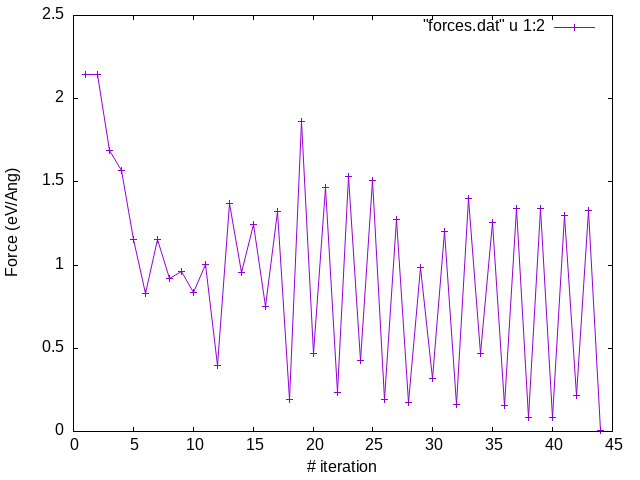

In [37]:
from IPython.display import Image
Image("max_force_iteration.png")


### This tutorial demonstrates how to perform constrained geometry optimization in SIESTA, where selected atoms and lattice vectors are fixed during relaxation, allowing controlled structural minimization while monitoring forces, stress, and energy convergence.